Imports and Data Loading

In [22]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_val = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

# Calculate number of input features based on preprocessing
num_features = X_train.shape[1]

X_train shape: (30687, 9)
y_train shape: (30687, 1)
X_val shape: (6576, 9)
y_val shape: (6576, 1)


In [23]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in X_val:", np.isnan(X_val).sum())
print("NaNs in y_val:", np.isnan(y_val).sum())

NaNs in X_train: 0
NaNs in y_train: 0
NaNs in X_val: 0
NaNs in y_val: 0


MLP ANN Architecture

In [24]:
# # FIRST MODEL: 3 Hidden Layers with Dropout
# model = keras.Sequential([
# # Input Layer
#     keras.layers.Dense(16, activation='relu', input_shape=(num_features,)),
#     keras.layers.Dropout(0.2),

# # Hidden Layer 2
#     keras.layers.Dense(12, activation='relu'),
#     keras.layers.Dropout(0.2),

# # Hidden Layer 3
#     keras.layers.Dense(8, activation='relu'),

# # Output Layer (1 continuous output: kWh)
#     keras.layers.Dense(1, activation='linear')
# ])

# # Compile
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss='mse',
#     metrics=['mae']
# )

# SECOND MODEL: Wider Layers with LeakyReLU and Huber Loss
model = keras.Sequential([
#Input Layer
    keras.layers.Dense(32, input_shape=(num_features,)),
    keras.layers.LeakyReLU(alpha=0.1),
    keras.layers.Dropout(0.15),

# Hidden Layer 2
    keras.layers.Dense(24),
    keras.layers.LeakyReLU(alpha=0.1),
    keras.layers.Dropout(0.15),

# Hidden Layer 3
    keras.layers.Dense(16),
    keras.layers.LeakyReLU(alpha=0.1),

# Output Layer
    keras.layers.Dense(1, activation='linear')
])

# Compile the model w/ Huber Loss
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(delta=1.0), # Better for noisy weather data than MSE
    metrics=['mae', 'mse'] 
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,529 (5.97 KB)

 Trainable params: 1,529 (5.97 KB)

 Non-trainable params: 0 (0.00 B)

Configuring Callbacks

In [25]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=15, 
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='../models/best_model_iloilo.keras',
        monitor='val_loss', 
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=7, 
        min_lr=1e-6,
        verbose=1
    )
]

Training the Model

In [26]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
474/480 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1269 - mae: 0.3559 - mse: 0.2929
Epoch 1: val_loss improved from None to 0.00642, saving model to ../models/best_model_iloilo.keras

Epoch 1: finished saving model to ../models/best_model_iloilo.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0570 - mae: 0.2359 - mse: 0.1231 - val_loss: 0.0064 - val_mae: 0.0830 - val_mse: 0.0128 - learning_rate: 0.0010
Epoch 2/200
460/480 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0125 - mae: 0.1171 - mse: 0.0251
Epoch 2: val_loss improved from 0.00642 to 0.00494, saving model to ../models/best_model_iloilo.keras

Epoch 2: finished saving model to ../models/best_model_iloilo.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0107 - mae: 0.1060 - mse: 0.0214 - val_loss: 0.0049 - val_mae: 0.0711 - val_mse: 0.0099 - learning_rate: 0.0010
Epoch 3/200
448/480 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0077 - mae: 0.0861 - mse: 0.0154
Epoch 3: val_loss did not improve from 0.00494


In [27]:
best_epoch = np.argmin(history.history['val_loss'])

best_val_huber = history.history['val_loss'][best_epoch]
best_train_huber = history.history['loss'][best_epoch]

best_val_mse = history.history['val_mse'][best_epoch]
best_train_mse = history.history['mse'][best_epoch]

best_val_mae = history.history['val_mae'][best_epoch]
best_train_mae = history.history['mae'][best_epoch]

print(f"\nBest Model Performance (Epoch {best_epoch + 1})")
print(f"Training Loss (Huber): {best_train_huber:.5f}")
print(f"Validation Loss (Huber): {best_val_huber:.5f}")
print(f"Training MSE:          {best_train_mse:.5f}")
print(f"Validation MSE:        {best_val_mse:.5f}")
print(f"Training MAE:          {best_train_mae:.5f}")
print(f"Validation MAE:        {best_val_mae:.5f}")


Best Model Performance (Epoch 43)
Training Loss (Huber): 0.00197
Validation Loss (Huber): 0.00197
Training MSE:          0.00394
Validation MSE:        0.00394
Training MAE:          0.03343
Validation MAE:        0.03331


Training History Plot

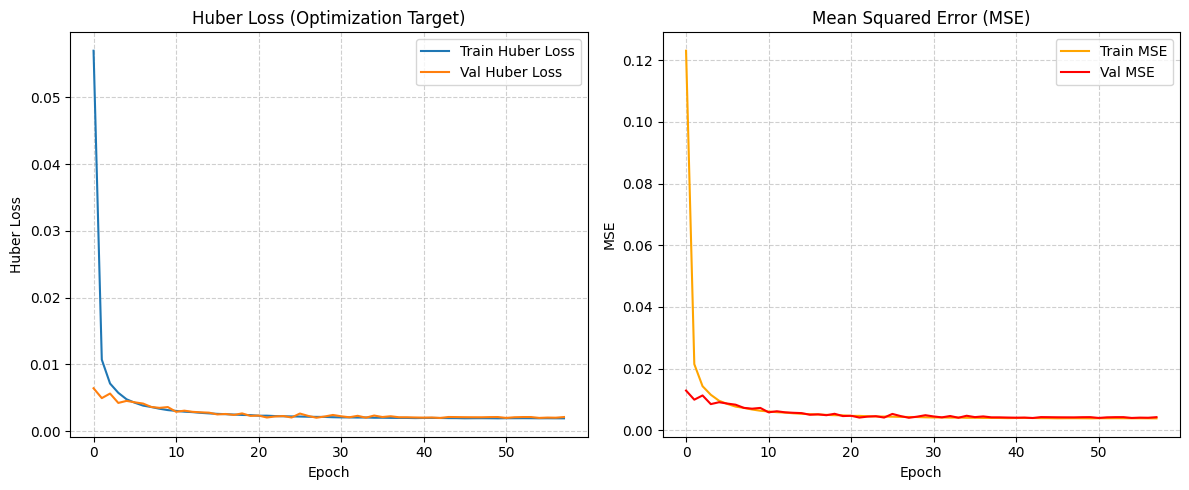

In [28]:
plt.figure(figsize=(12, 5))

# Huber Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Huber Loss')
plt.plot(history.history['val_loss'], label='Val Huber Loss')
plt.title('Huber Loss (Optimization Target)')
plt.ylabel('Huber Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# MSE (For human interpretability)
plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Train MSE', color='orange')
plt.plot(history.history['val_mse'], label='Val MSE', color='red')
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../figures/training_metrics_curves.png', dpi=300, bbox_inches='tight')
plt.show()